In [1]:
import numpy as np 
import warnings
from scipy.optimize import root_scalar
import model_constants as const
import pandas as pd 

In [2]:
## Given surface temperature and humidity, and, tropospheric relative humidity
## This simple plume model predicts the vertical profile of the environmental temperature
## and consequently the buoyancy of undiluted (CAPE) and weakly-diluted (extreme convection) plumes

## For zero-buoyancy plume model: model_type == 'zero-buoyancy'
#  environmental temperature is assumed to be neutral to that of bulk-entraining plume

## For spectal plume model: model_type == 'spectral'
#  environmental temperature is predicted from detraiment temperature of a
#  spectrum of plumes, by dropping the zero-buoayncy and bulk assumption

### Additional arguments to ZBP model

# powerk: Power parameter for relationship between entrainment rate and height [1.0]

# ent_fac: Constant for computing parameter u in spectral-plume model [0.18]

# eta: Constant for computing parameter u in spectral-plume model [0.75]

## Based on the Matlab code of Zhou and Xie (2019) https://sites.google.com/view/zhouwy/code-note

In [3]:
### function to check arguments are correct
def check_argument(var, varname, expected_type, varmin, varmax):
    """
    Check that an argument has the expected type and, if numeric,
    lies within the given bounds.

    Parameters
    ----------
    var : any
        Value to check.
    varname : str
        Name of the variable, used in error messages.
    expected_type : type or tuple[type, ...]
        Expected Python type, e.g. float, int, str, or (int, float).
    varmin : float
        Minimum allowed value for numeric inputs.
    varmax : float
        Maximum allowed value for numeric inputs.
    """
    if not isinstance(var, expected_type):
        if isinstance(expected_type, tuple):
            type_name = ", ".join(t.__name__ for t in expected_type)
        else:
            type_name = expected_type.__name__
        raise TypeError(f"Input: {varname} must be of type {type_name}")

    if isinstance(var, (int, float)):
        if var < varmin or var > varmax:
            raise ValueError(
                f"Input: {varname} outside of bounds [{varmin}, {varmax}]"
            )
    

In [4]:
def calc_fice(T, const=const):
    # Function to calculate the fraction of condensate that is ice.
    # All liquid for T > T0
    # All ice for T < T_ice
    # Linear function in between

    fliq = ( T-const.T_ice )/(const.T0-const.T_ice)
    if type(fliq)==float or type(fliq)==np.float64:
        if fliq<0:
            fliq=0
        elif fliq>1:
            fliq=1
    else:
        fliq[fliq<0] = 0
        fliq[fliq>1] = 1
    fice = 1-fliq

    return fliq, fice


def e_sat(T,const=const):
    # Function to calculate the saturation vapor pressure
    #
    # The functions are consistent with the constants given in the
    # model_constants subroutine. A faster option is available in which the
    # saturation curves are approximated as in Bolton (1980).
    #

    # Thermodynamically consistent definition of saturation curves
    # i.e. integral of Clausius-Clapeyron equation with constant heat
    # capacities. See Romps (2008).

    esl = const.e0*(T/const.T0)**((const.cpv-const.cpl)/const.Rv)* np.exp( ( const.Lv0 - const.T0*(const.cpv-const.cpl) )/const.Rv* ( 1/const.T0 - 1/T ) )

    esi = const.e0*(T/const.T0)**((const.cpv-const.cpi)/const.Rv)*np.exp( ( const.Ls0 - const.T0*(const.cpv-const.cpi) )/const.Rv* ( 1/const.T0 - 1/T ) )

    # If you want slightly faster (~10#) code, use these approximations 
    # (Bolton, 1980). Accurate to within 0.5# for T < 310 K.

    # esl = 611.2 *np. exp( 17.67      * ( T  - 273.15 ) / ( T  - 29.65 ) )
    # esi = 611.2 *np.exp( 21.8745584 * ( T  - 273.15 ) / ( T  - 7.66  ) )


    # Calculate ice fraction
    fliq,fice = calc_fice(T)

    es = fliq*esl + fice*esi

    return es, esl, esi

def qq_sat(T,p,qt=None, const=const):
    # Function to calculate the saturation specific humidity

    # Calculate saturation mixing ratio
    es, esl, esi = e_sat(T)
    rs = const.eps*es/(p-es)

    # Calculate saturation specific humidity using total water content if given
    if qt is not None:
        
        rt = qt/(1-qt)
        qs = rs/(1+np.nanmax([rt,rs]))
    else:
        qs = rs/(1+rs)
    
    return qs

def calc_saturation(p,T,q_t):
    # Function to calculate the specific humidities of vapor, liquid and solid
    # at saturation
    # calculate saturation specific humidity
    qs = qq_sat(T,p,q_t)
    q = np.minimum(q_t,qs)
    if type(q)==np.float64:
        if q<0:
            q=0
    else:
        q[q<0] = 0

    # Divide into liquid and ice
    fliq,fice = calc_fice(T)

    ql = fliq*(q_t-q)
    qi = fice*(q_t-q)

    if type(ql)==np.float64:
        if q_t-qs<0:
            ql=0
            qi=0
    else:
        ql[q_t-qs<0] = 0
        qi[q_t-qs<0] = 0


    return q,ql,qi

def calc_MSE(T,qt,p,z,const=const):
    # Function to calculate moist static energy

    # calculate proportions of vapor, liquid and solid
    qv,ql,qi = calc_saturation(p,T,qt)


    # calculate moist static energies of components
    hd = const.cp*(T-const.T0)  + const.g*z
    hv = const.cpv*(T-const.T0) + const.g*z + const.Lv0
    hl = const.cpl*(T-const.T0) + const.g*z
    hi = const.cpi*(T-const.T0) + const.g*z - (const.Ls0-const.Lv0)

    # Calculate moist static energy per unit mass of moist air
    # h = hd*(1-qt) + qv*hv + ql*hl + qi*hi
    ## SPM doesn't include liquid and ice effect
    h = hd*(1-qt) + qv*hv

    return h

In [5]:
def calc_Tv(T,RH,p,const=const):
    # Function to calculate virtual temperature at a given relative humidity

    # Calculate mixing ratio
    es, esl, esi  = e_sat(T)
    qv = const.eps*(RH*es/(p-RH*es*(1-const.eps)))

    # calculate virtual temperature
    Tv = T*(1+qv/const.eps-qv)

    return Tv

def fallout(gamma,ql,qi,dqls,T):
    # Function to calculate precipitation fallout terms

    e = np.minn([0,dqls/(1-ql-qi) ])

    fT = -gamma*e
    fliq,fice = calc_fice(T)

    fl = fT*fliq
    fs = fT*fice

    return fl, fs

In [6]:
def spectral_plume(model_type="spectral",T_base = 300., qt_base = 0.0155, p_base= 100000., entrain = 0.5, RH = 0.7, 
                        z_base = 50., z_top = 15000., powerk = 1.0 , deltaz = 50., ent_fac  = 0.18, eta = 0.75, P=3.,
                        const=const, plotting = True,save_data=True):
    ## check input argument types first
    check_argument(model_type,'model_type',(str),       0 , 0)  # 'zero-buoyancy' or 'spectral'
    check_argument(T_base     ,'T_base'     ,(int,float), 0     ,500   )  # K
    check_argument(qt_base    ,'qt_base'    ,(int,float), 0     ,1     )  # kg/kg
    check_argument(p_base     ,'p_base'     ,(int,float), 0     ,np.inf)  # Pa
    check_argument(entrain   ,'entrain'   ,(int,float), 0     ,np.inf)
    check_argument(RH        ,'RH'        ,(int,float), 0     ,1     )
    check_argument(z_base     ,'z_base'     ,(int,float), 0     ,z_top )  # m
    check_argument(z_top     ,'z_top'     ,(int,float), z_base, np.inf)
    check_argument(powerk    ,'powerk'    ,(int,float), 0     ,4     )
    check_argument(deltaz    ,'deltaz'    ,(int,float), 0     ,200   ) # m 
    check_argument(ent_fac   ,'ent_fac'   ,(int,float), 0.    ,1     )
    check_argument(eta       ,'eta'       ,(int,float), 0.5   ,2     )
    
    ## Set up height
    z = np.arange(z_base, z_top + deltaz, deltaz)
    if np.abs(z[-1] - z_top) > 0.1:
        z = np.append(z, z_top) # ensure last point is exactly z_top
    
    ## Entrainment profile ####################################################

    # set entrainment rate as function of z:
    # For zero-buoayncy plume model, it means the entraiment rate of the bulk
    # plume at this level z, decreasing with height as this function
    # For spectral plume model, it defines the entraiment rate of the plume
    # that detrains at this level z
    ent = 0.001*entrain*np.minimum(1.,np.maximum(0.,(z_top-z)/z_top))**powerk
    # set entrainment rate of the weakly-entrained plume
    ent_w = 0.001*entrain*np.ones_like(z)*ent_fac
    
    ## Initialize arrays to hold plume properties
    p       = np.zeros_like(z)
    logp    = np.zeros_like(z)

    qv      = np.zeros_like(z)
    qsat    = np.zeros_like(z)
    ql      = np.zeros_like(z)
    qi      = np.zeros_like(z)
    

    T       = np.zeros_like(z)
    T_rho   = np.zeros_like(z)

    h       = np.zeros_like(z)

    T_env   = np.zeros_like(z)
    q_env   = np.zeros_like(z)
    h_env   = np.zeros_like(z)
    
    # undiluted plume (moist adiabat with zero entraiment), according to
    # definition of CAPE (convective available potential energy)
    T_u     = np.zeros_like(z)
    T_rho_u = np.zeros_like(z)
    qv_u    = np.zeros_like(z)
    h_u     = np.zeros_like(z)
    B_u     = np.zeros_like(z)
    CAPE_u  = 0.
    T_u[0]  = T_base
    qv_u[0] = qt_base

    # weakly-entrained plume, as a representation of the extreme convection
    T_w     = np.zeros_like(z)
    T_rho_w = np.zeros_like(z)
    qv_w    = np.zeros_like(z)
    h_w     = np.zeros_like(z)
    B_w     = np.zeros_like(z)
    CAPE_w  = 0.
    T_w[0]  = T_base
    qv_w[0] = qt_base
    
    ## Initial conditions
    p[0] = p_base
    T[0] = T_base
    qv[0] = qt_base
    
    ## Derived properties 
    logp[0] = np.log(p[0])
    h[0] = calc_MSE(T[0],qv[0],p[0],z[0])
    h_u[0]   = h[0]
    h_w[0]   = h[0]
    
    ## Flag for LCL level
    LCL = 0
    
    ## Integrate model upward
    for i in range(0,len(z)):
        # Calculate undiluted plume density temperature, buoyancy and CAPE
        T_rho[i] = T[i]*(1+qv[i]/const.eps-qv[i])
        T_rho_u[i] = T_u[i]*(1+qv_u[i]/const.eps-qv_u[i])
        B_u[i] = const.g*(T_rho_u[i]-T_rho[i])/T_rho[i]
        CAPE_u = CAPE_u+B_u[i]*deltaz
        
        # Calculate weakly-entrained plume density temperature, buoyancy and CAPE
        T_rho_w[i] = T_w[i]*(1+qv_w[i]/const.eps-qv_w[i])
        B_w[i] = const.g*(T_rho_w[i]-T_rho[i])/T_rho[i]
        CAPE_w = CAPE_w+np.maximum(B_w[i],0)*deltaz
        
        # Calculate plume saturation specific humidity
        qsat[i] = qq_sat(T[i],p[i])
        # Calculate environment properties
        T_env[i] = root_scalar(lambda x: calc_Tv(x, RH, p[i]) - T_rho[i],
                               x0=T[i] * (1 + 0.61 * RH * qv[i]),
                               method="newton"
                               )["root"]
        
        # Calculate environment humidity based on assumed relative humidity
        es_tmp, _, _ = e_sat(T_env[i])
        e_env = RH*es_tmp
        q_env[i] = const.eps*(e_env/(p[i]-e_env*(1-const.eps)))
        
        # Calculate environment moist static energy
        h_env[i] = calc_MSE(T_env[i],q_env[i],p[i],z[i])
        
        if i<len(z)-1:
            # No entrainment if unsaturated
            # Include LCL flag to prevent entrainment turning off above LCL
            if (qv[i]-qsat[i]) < 0 and LCL == 0:
                ent[i]=0
                ent_w[i] = 0
                z_lcl = i
            else:
                LCL = 1
        
            ## Step upward - simple Euler method
            
            if LCL == 1:
                
                if model_type=='spectral':
                    if ent[i]!=0.:
                        if z[i]<z_top:
                            dent = (ent[i]-ent[i-1])/ent[i]
                        else:
                            dent = 0.
                        h[i+1] = h[i] - ent[i]*( h[i] - h_env[i] ) *( z[i+1]-z[i] ) - (h[0] - h[i])*dent/(1+eta*ent[i]*(z[i]-z[z_lcl]))
                    else:
                        h[i+1] = h[i]

                elif model_type=='zero-buoyancy':
                    h[i+1] = h[i] - ent[i]*( h[i] - h_env[i] )*( z[i+1]-z[i] )
                else:
                    raise ValueError("Invalid model_type. Must be 'spectral' or 'zero-buoyancy'.")
            else:
                h[i+1] = h[i] 
                
            h_u[i+1] = h_u[i]
            
            h_w[i+1] = h_w[i] - ent_w[i]*( h_w[i] - h_env[i] ) *( z[i+1]-z[i] )
            
            logp[i+1] = logp[i] - const.g/(const.Rd*T_rho[i])*( z[i+1]-z[i] )
            
            ## Calculate pressure
            p[i+1]  = np.exp(logp[i+1])

            # Calculate Temperature via root finding algorithm
            T[i+1] = root_scalar(lambda x: calc_MSE(x, qv[i], p[i+1], z[i+1]) - h[i+1],
                                x0=T[i], method="newton"
                            )["root"]

    
            # Calculate Undiluted Temperature via root finding algorithm
            T_u[i+1] = root_scalar(lambda x: calc_MSE(x, qv_u[i], p[i+1], z[i+1]) - h_u[i+1],
                                x0=T_u[i], method="newton"
                            )["root"]
            
            # Calculate Weakly Diluted Temperature via root finding algorithm
            T_w[i+1] = root_scalar(lambda x: calc_MSE(x, qv_w[i], p[i+1], z[i+1]) - h_w[i+1],
                                x0=T_w[i], method="newton"
                            )["root"]

            # Calculate specific humidity
            qv[i+1] = np.minimum(qq_sat(T[i+1],p[i+1]),qv[i])
            
            # Calculate undilated specific humidity
            qv_u[i+1] = np.minimum(qq_sat(T_u[i+1],p[i+1]),qv_u[i])
            
            # Calculate undilated specific humidity
            qv_w[i+1] = np.minimum(qq_sat(T_w[i+1],p[i+1]),qv_w[i])
    
    #### end of for loop
    h_w = np.maximum(h_w,h)
    T_w = np.maximum(T_w,T_env)
    T_rho_w = np.maximum(T_rho_w,T_rho)
    qv_w = np.maximum(qv_w,qv)

    rhs = qt_base/qq_sat(T_base,p_base)
    
    ### CoPilot helped me explaine the for loop below
    # Adjust environment temperature and humidity below LCL to be 
    # consistent with the assumed relative humidity,
    # which is not guaranteed by the model integration above
    for i in range(0,len(z)):
        if i<=z_lcl:
            rh = RH+(rhs-RH)*(z[z_lcl]+z_base-z[i])/z[z_lcl]
            # Use root finding algorithm with initial guess
            T_env[i] = root_scalar(lambda x: calc_Tv(x, RH, p[i]) - T_rho[i],
                               x0=T[i] * (1 + 0.61 * RH * qv[i]),
                               method="newton"
                               )["root"]
            
            # Calculate environment humidity based on assumed relative humidity
            es_tmp, _, _ = e_sat(T_env[i])
            e_env = rh*es_tmp
            q_env[i] = const.eps*(e_env/(p[i]-e_env*(1-const.eps)))

            # Calculate environment moist static energy
            h_env[i] = calc_MSE(T_env[i],q_env[i],p[i],z[i])

    h[z>z_top]=np.nan
    T[z>z_top]=np.nan
    T_rho[z>z_top]=np.nan
    
        
    df = pd.DataFrame({
            "z": z,
            "p": p,
            "T_rho": T_rho,
            "T": T,
            "qv": qv,
            "h": h,
            "T_env": T_env,
            "q_env": q_env,
            "h_env": h_env,
            "T_rho_u": T_rho_u,
            "T_u": T_u,
            "qv_u": qv_u,
            "h_u": h_u,
            "CAPE_u": CAPE_u,
            "B_u": B_u,
            "T_rho_w": T_rho_w,
            "T_w": T_w,
            "qv_w": qv_w,
            "h_w": h_w,
            "CAPE_w": CAPE_w,
            "B_w": B_w,
            "ent": ent,
        })
    if save_data:
        df.to_csv(f'{model_type}_output.csv', index=False)
        
    if plotting:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(7, 8))

        plt.plot(h/1000,z/1000, "r", label="plume")
        plt.plot(h_env/1000,z/1000, "b", label="environment")
        plt.xlabel("MSE (kJ/kg)")
        plt.ylabel("z (km)")
        plt.title("Spectral plume profiles")
        plt.legend()
        plt.savefig("Spectral_plume_profiles.png", dpi=300)
    return df

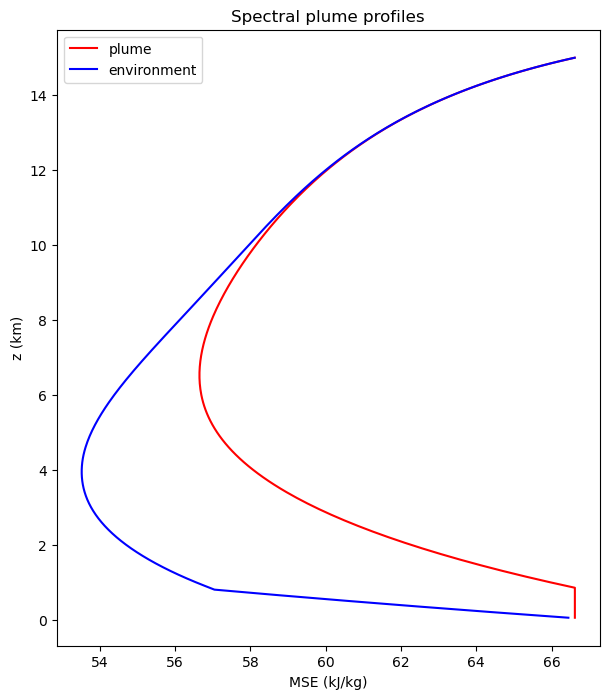

In [7]:
if __name__ == "__main__":
    output = spectral_plume(model_type="spectral", plotting=True, save_data=True)